# Data Preparation

In [34]:
# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk
from sentence_transformers import SentenceTransformer
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")


In [14]:
# Read the csv file
df = pd.read_csv("DataSet.csv")

In [15]:
# Get column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17880 non-null  object
 1   location             17534 non-null  object
 2   department           6333 non-null   object
 3   salary_range         2868 non-null   object
 4   company_profile      14572 non-null  object
 5   description          17880 non-null  object
 6   requirements         15191 non-null  object
 7   benefits             10684 non-null  object
 8   telecommuting        17880 non-null  object
 9   has_company_logo     17880 non-null  object
 10  has_questions        17880 non-null  object
 11  employment_type      14409 non-null  object
 12  required_experience  10830 non-null  object
 13  required_education   9775 non-null   object
 14  industry             12977 non-null  object
 15  function             11425 non-null  object
 16  frau

In [16]:
# Drop all duplicate rows, keeping the first occurrence
df = df.drop_duplicates(keep='first')

# Check the new shape
print(f"New dataset shape: {df.shape}")

New dataset shape: (17645, 18)


In [17]:
# Drop unnecessary rows (Based on EDA)

df = df.drop(columns=['salary_range', 'in_balanced_dataset', 'department'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17645 entries, 0 to 17879
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17645 non-null  object
 1   location             17302 non-null  object
 2   company_profile      14358 non-null  object
 3   description          17645 non-null  object
 4   requirements         14995 non-null  object
 5   benefits             10542 non-null  object
 6   telecommuting        17645 non-null  object
 7   has_company_logo     17645 non-null  object
 8   has_questions        17645 non-null  object
 9   employment_type      14210 non-null  object
 10  required_experience  10669 non-null  object
 11  required_education   9617 non-null   object
 12  industry             12796 non-null  object
 13  function             11267 non-null  object
 14  fraudulent           17645 non-null  object
dtypes: object(15)
memory usage: 2.2+ MB


In [18]:
# Convert data types

# Convert 'fraudulent' to 0/1 integers
df['fraudulent'] = df['fraudulent'].map({'t': 1, 'f': 0}).astype(int)

# Categorical columns to 'category' dtype
categorical_cols = [
    'telecommuting', 'has_company_logo', 'has_questions',
    'employment_type', 'required_experience', 'required_education',
    'industry', 'function', 'location'
]

df[categorical_cols] = df[categorical_cols].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17645 entries, 0 to 17879
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   title                17645 non-null  object  
 1   location             17302 non-null  category
 2   company_profile      14358 non-null  object  
 3   description          17645 non-null  object  
 4   requirements         14995 non-null  object  
 5   benefits             10542 non-null  object  
 6   telecommuting        17645 non-null  category
 7   has_company_logo     17645 non-null  category
 8   has_questions        17645 non-null  category
 9   employment_type      14210 non-null  category
 10  required_experience  10669 non-null  category
 11  required_education   9617 non-null   category
 12  industry             12796 non-null  category
 13  function             11267 non-null  category
 14  fraudulent           17645 non-null  int64   
dtypes: category(9), int64(1)

In [19]:
# Create binary column for existence of company_profile
df['has_company_profile'] = df['company_profile'].notnull().astype('category')

# Drop the original column
df = df.drop(columns=['company_profile'])

# Quick check by fraud status
print(df.groupby('fraudulent')['has_company_profile'].value_counts(normalize=True))


fraudulent  has_company_profile
0           True                   0.838804
            False                  0.161196
1           False                  0.677156
            True                   0.322844
Name: proportion, dtype: float64


In [20]:
# Function to clean individual text fields
def clean_text_for_sbert(text):
    if pd.isna(text):
        return ""
    
    # Remove HTML tags
    soup = BeautifulSoup(text, "html.parser")
    clean_text = soup.get_text(separator=" ")
    
    # Normalize whitespace
    clean_text = " ".join(clean_text.split())
    
    # Lowercase 
    clean_text = clean_text.lower()
    
    # Remove long sequences of non-word characters (like underscores, $$$, etc.)
    clean_text = re.sub(r'[_\W]{2,}', ' ', clean_text)
    
    return clean_text

# Apply cleaning to each column
text_columns = ['title', 'description', 'requirements', 'benefits']
for col in text_columns:
    df[f'clean_{col}'] = df[col].apply(clean_text_for_sbert)

# Concatenate cleaned columns for SBERT embedding
df['text_for_embedding'] = (
    df['clean_title'] + " " +
    df['clean_description'] + " " +
    df['clean_requirements'] + " " +
    df['clean_benefits']
)


In [21]:
# Target variable
y = df['fraudulent'].values

# Perform a 80 - 20 train test split on the dataset. Stratified to preserve class distribution
df_train, df_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42, stratify=y
)


In [22]:
# Frequency encode the location column to reduce dimensionality
# Replace each category with the proportion of times it appears in the training set (Number of postings in that location / Total number of postings in training set)
# For categories in the test set, values are mapped using the frequencies calculated from the training set. 
# Categories not seen in the training set are assigned a value of 0.

def frequency_encoding(train_series, test_series):
    freq = train_series.value_counts(normalize=True)
    train_encoded = train_series.map(freq).fillna(0)
    test_encoded = test_series.map(freq).fillna(0)  # unseen categories become 0
    return train_encoded, test_encoded

df_train['location'], df_test['location'] = frequency_encoding(
    df_train['location'], df_test['location']
)


Considerations on why frequency encoding is used for "Location":

1) Contains over 3000 unique values: Results in very high dimensional data if one hot encoding is used. Frequency encoding helps to reduce it into a single numerical value.

Limitations:

1) Loses target signal: Frequency encoding only reflects how common a location is, not its relationship with fraud. 

    Solution: Consider using target encoding to replace location with fraud rate (Number of fraud postings at that location / total postings at that location). 

    Possible problems: Locations that are correlated with fraud may change over time.

In [23]:
# Text column
text_col = 'text_for_embedding'

In [24]:
# Load a pre-trained SBERT model for generating text embeddings
# Fixed length vector of 384 dimensions.

model = SentenceTransformer('all-MiniLM-L6-v2')

# Train embeddings
train_embeddings = model.encode(df_train[text_col].tolist(), batch_size=32, show_progress_bar=True)

# Test embeddings
test_embeddings = model.encode(df_test[text_col].tolist(), batch_size=32, show_progress_bar=True)


Batches: 100%|██████████| 111/111 [00:18<00:00,  5.91it/s]


Considerations on why SBERT is used for text embedding

Benefits:

1) Captures semantic meaning: Fraudulent job descriptions may vary their choice of words to prevent getting detected by fraud detection models. SBERT captures the underlying meaning of sentences, so even if different words or phrasing are used, similar fraudulent content will have similar embeddings, improving the model’s ability to generalize.

2) Fixed length, dense vector representation: SBERT embeds text into a numerical vector of fixed size, regardless of the length of the input. This keeps the embedding dense and relatively low dimensional, resulting in faster training, low memory usage and less risk of overfitting.

Challenges:

1) Fixed length embeddings might lose fine grained info. Solution: Embed the different text columns separately to preserve column specific semantic information. Perform dimension reduction (e.g., PCA) to prevent overfitting.

2) Pretrained model may not generalize. Solution: Fine tune the SBERT model using our training data.


In [25]:
# Separate numeric/binary and categorical columns
numeric_cols = ['location']

categorical_cols = ['employment_type', 'required_experience', 
                    'required_education', 'industry', 'function', 'telecommuting', 'has_company_logo', 
                    'has_questions', 'has_company_profile']

# Extract numeric features as float
X_train_num = df_train[numeric_cols].astype(np.float32).values
X_test_num  = df_test[numeric_cols].astype(np.float32).values

# Extract categorical features
X_train_cat = df_train[categorical_cols]
X_test_cat  = df_test[categorical_cols]


In [26]:
# Convert categorical columns to integer codes
X_train_cat_codes = X_train_cat.apply(lambda x: x.cat.codes).values

# Combine numeric + categorical codes + embeddings for SMOTE-NC
X_train_combined = np.hstack([X_train_num, X_train_cat_codes, train_embeddings])

# Similarly combine test features (for later evaluation)
X_test_combined = np.hstack([
    X_test_num,
    X_test_cat.apply(lambda x: x.cat.codes).values,
    test_embeddings
])

# Define indices of categorical columns in the combined array
categorical_indices = [i for i in range(len(numeric_cols), len(numeric_cols) + len(categorical_cols))]

# Initialize SMOTE-NC
smote_nc = SMOTENC(
    categorical_features=categorical_indices,
    sampling_strategy=0.5,  # minority class will reach 50% of majority
    random_state=42
)

# Apply SMOTE-NC on the training set only
X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train_combined, y_train)

# Check the new class distribution
print(Counter(y_train_resampled))


Counter({np.int64(0): 13430, np.int64(1): 6715})


In [27]:
# Rename for clarity
X_train = X_train_resampled
y_train = y_train_resampled
X_test = X_test_combined
y_test = y_test

Here, we run SMOTE-NC to resample the training dataset so that the minority (fraudulent) class is increased to 50% of the majority class. SMOTE-NC is only performed after the train-test-split to avoid any data leakage from the test set.

We run SMOTE-NC because the dataset is highly imbalanced and this can result in the model being biased towards predicting the majority class. By generating synthetic samples for the minority class, this can help the model learn a more balanced representation of the data.

Challenges: SMOTE-NC might not be useful if classes are highly overlapping. 

Solution: Compare model performance with and without SMOTE-NC to assess whether it improves results.

In summary, now we have X_train, y_train, X_test, y_test that is ready to be piped into the LightGBM model.

In [35]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"


# Define LightGBM model
model = LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    verbose = -1
)

# Fit with early stopping using callbacks
model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_train_resampled, y_train_resampled), (X_test_combined, y_test)],
    eval_metric=['auc', 'average_precision'],
    callbacks=[early_stopping(stopping_rounds=100), log_evaluation(50)]
)

# Predict probabilities for positive class
y_pred_proba = model.predict_proba(X_test_combined)[:, 1]


Training until validation scores don't improve for 100 rounds
[50]	training's auc: 0.994213	training's average_precision: 0.990516	training's binary_logloss: 0.152079	valid_1's auc: 0.956318	valid_1's average_precision: 0.736136	valid_1's binary_logloss: 0.142679
[100]	training's auc: 0.999417	training's average_precision: 0.998909	training's binary_logloss: 0.0686141	valid_1's auc: 0.967525	valid_1's average_precision: 0.785715	valid_1's binary_logloss: 0.0950543
[150]	training's auc: 0.999956	training's average_precision: 0.999912	training's binary_logloss: 0.0358616	valid_1's auc: 0.972849	valid_1's average_precision: 0.814632	valid_1's binary_logloss: 0.0763434
[200]	training's auc: 0.999999	training's average_precision: 0.999997	training's binary_logloss: 0.0205789	valid_1's auc: 0.973327	valid_1's average_precision: 0.828928	valid_1's binary_logloss: 0.0683031
[250]	training's auc: 1	training's average_precision: 1	training's binary_logloss: 0.0126636	valid_1's auc: 0.97482	valid

/Users/jjong/Desktop/GovTech Assessment/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0     0.9835    0.9946    0.9890      3357
           1     0.8657    0.6744    0.7582       172

    accuracy                         0.9790      3529
   macro avg     0.9246    0.8345    0.8736      3529
weighted avg     0.9778    0.9790    0.9778      3529

ROC-AUC: 0.9768
PR-AUC: 0.8489


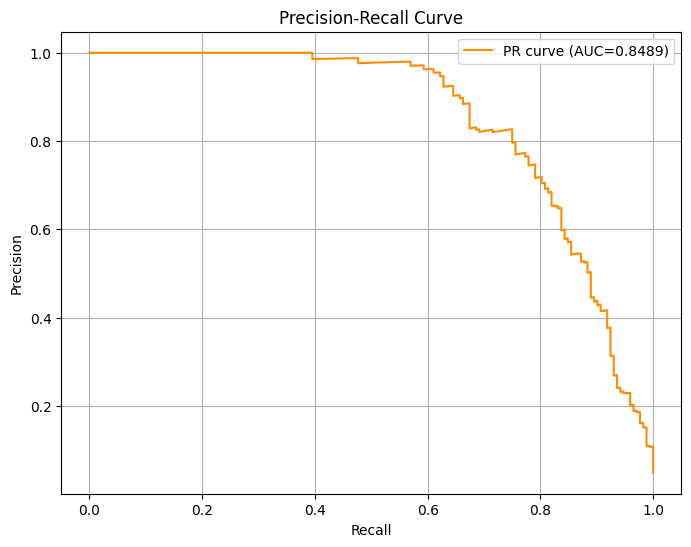

In [29]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    classification_report
)

# Choose a threshold (default 0.5) to convert probabilities into class labels
threshold = 0.5
y_pred = (y_pred_proba >= threshold).astype(int)

# Classification report
print(classification_report(y_test, y_pred, digits=4))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC:", round(roc_auc, 4))

# PR-AUC (average precision)
pr_auc = average_precision_score(y_test, y_pred_proba)
print("PR-AUC:", round(pr_auc, 4))

# Precision-Recall curve
prec, rec, thresh = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(rec, prec, label=f'PR curve (AUC={pr_auc:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Find threshold for high recall (e.g., >= 0.8)
pr_df = pd.DataFrame({'precision': prec[:-1], 'recall': rec[:-1], 'threshold': thresh})
best_thresh = pr_df.loc[pr_df['recall'] >= 0.8].sort_values('precision', ascending=False).head(1)
print("Best threshold for recall>=0.8:\n", best_thresh)

Best threshold for recall>=0.8:
       precision    recall  threshold
3177    0.71875  0.802326   0.173586


The LightGBM model was trained on the resampled dataset and initially achieved a recall of 0.67 for the fraudulent class using the default 0.5 probability threshold. 

To increase recall, we optimized the prediction threshold using the precision-recall curve, targeting a recall of at least 0.8. This adjustment increases the model’s ability to detect more fraudulent postings, but it comes at the cost of lower precision, meaning some legitimate postings are incorrectly flagged as fraud. 

Due to limited computational resources, hyperparameter tuning was not performed. However, even with the default parameters, the LightGBM model was able to achieve reasonable performance, and further tuning could potentially improve recall, precision, and overall F1-score. 